In [ ]:
# Actualy when we work with rag we moslty use its frameworks like langChain and other 
# But before that i want to know what just happening in RAG mechanisim


# SO we know tha RAG pipline right 
#  Documents -> Embedding -> Vectordatabase(here vetor indexing)
# User Query -> query Embedding -> similarity search -> retrival from the documents -> prompt -> LLM ->  Answer 

# As  we are doing with out any cloud based model 
# we create a bascic text and we use that for now as our LLM :)

In [1]:
documents = [
    """
    RAG stands for Retrieval-Augmented Generation.
    It retrieves relevant external information and provides
    that information to a language model before generation.
    """,

    """
    Embeddings are numerical vector representations of text.
    They allow systems to compare the semantic similarity
    between pieces of text.
    """,

    """
    Chunking is the process of splitting large documents
    into smaller pieces so that relevant information can
    be retrieved efficiently.
    """,

    """
    A vector database stores vector representations and
    allows similarity search over those vectors.
    """
]

In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(documents)

print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(4, 384)


In [3]:
# so embeddings are crates as 4 docs with dimmenions 384 lets check 

print(embeddings[0])

[-7.70811960e-02  6.04334995e-02 -2.93089240e-03  4.00723238e-03
 -8.84510204e-02  5.73513694e-02  3.48842628e-02  1.51766147e-02
  1.31420605e-02 -5.57956137e-02  3.90265770e-02  1.84161738e-02
  8.10501203e-02 -6.92936406e-02 -3.17312144e-02  5.06461151e-02
  2.54700277e-02  8.81577060e-02 -2.79788263e-02 -5.31310029e-02
 -9.95396287e-04  7.76633024e-02  2.14218255e-02 -6.00178540e-02
  4.18028347e-02  3.91418599e-02 -7.46866688e-02  5.43857599e-03
  1.37121186e-01  9.90909338e-03  4.86700283e-03  1.18363641e-01
 -9.80577432e-03  8.74707196e-03 -6.13694452e-02  5.15473485e-02
 -4.13789153e-02  8.85664299e-02  5.76538849e-04  4.90762386e-03
 -3.33383903e-02  3.40145752e-02 -9.24710184e-03 -5.41300178e-02
  3.69339660e-02 -4.83686430e-03 -5.05867004e-02  4.61854739e-03
 -4.64460440e-02  3.23243923e-02 -5.00220656e-02  5.63070271e-03
  4.63631675e-02  3.98031212e-02 -2.91747786e-02 -3.46607119e-02
  8.29848722e-02 -2.67460793e-02 -4.30928431e-02  4.31905081e-03
 -8.04208070e-02 -7.39790

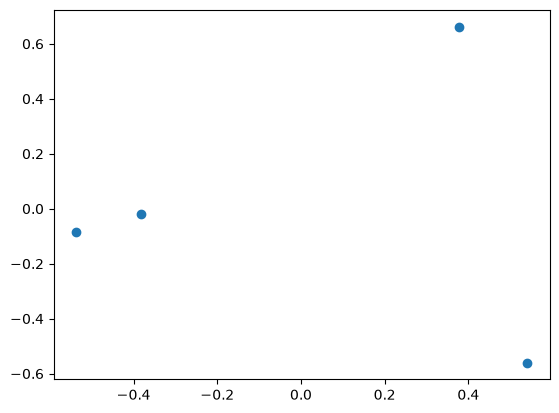

In [4]:
 # we can visulaize it by dimensionlaity reduciton
# for that we use PCA

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

reduced = pca.fit_transform(embeddings)
plt.scatter(
    reduced[:, 0],
    reduced[:, 1]
)


plt.show()



In [7]:
# now creatino vecotr indexing which is volatile 
# indexing is same as vector dabase but volatile.
# FAISS uses the euclideian search here 


import faiss
import numpy as np

embeddings = np.array(embeddings).astype("float32")

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print(index.ntotal)

4


In [ ]:
# we sre done with document toring so lets go with user view

# Retrival (User Query -> query Embedding -> similarity search -> retrival from the documents) ->Generaiton (prompt - > LLM ->  Answer )


In [11]:
query = "How does RAG retrieve information?"

In [13]:
# embedding the quesry

query_embedding = model.encode([query])
query_embedding = np.array(query_embedding).astype("float32")

print(query_embedding)

[[-2.79781930e-02  1.02575876e-01 -1.61576774e-02  4.32331953e-03
  -6.10397942e-02  4.16215416e-03  4.18105237e-02 -3.75999417e-03
   2.99219671e-03 -6.47920975e-03  2.95955949e-02  9.57076997e-02
   2.94418409e-02 -7.95604065e-02 -8.21826607e-02  3.22837420e-02
   4.16922718e-02  1.19588509e-01 -7.06260353e-02 -4.25074436e-02
   6.78178214e-04  3.15209441e-02 -4.71500726e-03 -7.25936741e-02
   2.39517447e-02  7.49654099e-02 -9.81110036e-02 -8.75252206e-03
   7.48589784e-02 -6.87680617e-02  1.52158504e-03  4.64824215e-02
  -1.42133832e-02  2.47057490e-02 -4.79857661e-02  3.78168300e-02
  -4.05070260e-02  6.87658116e-02  1.57302953e-02 -1.02124165e-03
   8.35793675e-04  2.54156757e-02 -2.52725165e-02 -2.46472307e-03
   4.34511602e-02  5.69044426e-02 -4.71145939e-03  2.40529440e-02
   2.12320257e-02  8.91003944e-03 -8.15041289e-02  8.37899093e-03
   4.16475572e-02  9.01359841e-02 -4.85172346e-02 -2.27663107e-02
   4.19824384e-02 -5.21378145e-02 -4.71944734e-02  7.73457736e-02
  -4.72292

In [14]:
# search th  query 

k = 2

distances, indices = index.search(query_embedding, k)

print(indices)
print(distances)

[[0 2]]
[[0.53929305 1.3561523 ]]


In [15]:
# retrival..
for i in indices[0]:
    print(documents[i])
    print("---")


# here we retrivied the top 2 of matchngs


    RAG stands for Retrieval-Augmented Generation.
    It retrieves relevant external information and provides
    that information to a language model before generation.
    
---

    Chunking is the process of splitting large documents
    into smaller pieces so that relevant information can
    be retrieved efficiently.
    
---


In [16]:
# so now wee need the t ogive this retrivala nd query to the llm so
# rerival doc  -> context -> prompt - > LLM ->  Answer 


In [19]:
def retrieve(query, k=2):
    query_embedding = model.encode([query])
    query_embedding = np.array(query_embedding).astype("float32")

    distances, indices = index.search(query_embedding, k)

    results = [documents[i] for i in indices[0]]

    return results

In [20]:
# lets try eith another query ...

results = retrieve("What is an embedding?", k=2)

for result in results:
    print(result)


    Embeddings are numerical vector representations of text.
    They allow systems to compare the semantic similarity
    between pieces of text.
    

    A vector database stores vector representations and
    allows similarity search over those vectors.
    


In [21]:
def build_prompt(query, retrieved_documents):

    context = "\n\n".join(retrieved_documents)

    prompt = f""" You are a helpful assistant.
            
            Answer the question using only the provided context.
            
            If the context does not contain the answer,
            say that you do not have enough information.
            
            Context:
            {context}
            
            Question:
            {query}
            
            Answer:
            """

    return prompt

In [22]:
results = retrieve(
    "What are embeddings?",
    k=2
)

prompt = build_prompt(
    "What are embeddings?",
    results
)

print(prompt)


You are a helpful assistant.

Answer the question using only the provided context.

If the context does not contain the answer,
say that you do not have enough information.

Context:

    Embeddings are numerical vector representations of text.
    They allow systems to compare the semantic similarity
    between pieces of text.
    


    A vector database stores vector representations and
    allows similarity search over those vectors.
    

Question:
What are embeddings?

Answer:



In [ ]:
#  When we are done with retrival then e need to evaluate the retical based on some metrics.




In [ ]:
# And one more thine we do in RAG is caching 
#     caching in a Retrieval-Augmented Generation (RAG) pipeline (often called Prompt Caching or Semantic Caching), 
#     the system doesn't just cache one isolated piece. It caches the mapping between the Query and the Final Answer.

# we have diffreent caching 

    # Depending on where you implement the cache in your pipeline, it stores different items:

    # Semantic Cache stores Responses (or query-answer pairs). 
    #     Its main purpose is to skip the entire RAG pipeline completely;
    #     if a user asks a question that is semantically similar to a previous one, 
    #     the system instantly delivers the saved text answer without running a vector search or calling the LLM.
            
    # LLM/Prompt Cache stores Prefixes (or context documents). 
    #         This method keeps heavy reference texts, chunks, and system instructions active inside the language 
    #         model's immediate memory so that the LLM does not have to spend time or tokens re-reading 
    #         the exact same background documents for every subsequent question.
    
    # Embedding Cache stores Vectors.
    #     This strategy maps exact text inputs directly to their calculated mathematical representations,
    #     allowing the system to instantly retrieve the numbers from storage and avoid paying API costs
    #     or computing power to re-encode the identical text string twice.
